In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load Halo4 dataset
df = pd.read_csv("Halo4.csv")

# Display first rows
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.353884e+09,257,i.imgur.com,13s436,Every time I level up in halo 4(x-post from r/...,ThatBrownGuy35,280,23,6,http://www.reddit.com/r/Halo4/comments/13s436/...,NaN,NaN,False,http://f.thumbs.redditmedia.com/J3PU39fSRecaph...,t5_2sjls,False,NaN,NaN,False,t3_13s436,http://i.imgur.com/GuApq.jpg,NaN
1,1.357096e+09,204,imgur.com,15syrr,How I feel when I get an assist after using th...,NAHHHBRO,225,21,33,http://www.reddit.com/r/Halo4/comments/15syrr/...,NaN,NaN,False,http://a.thumbs.redditmedia.com/U0WbwZA2pjlkDW...,t5_2sjls,False,NaN,NaN,False,t3_15syrr,http://imgur.com/19QTG,NaN
2,1.352617e+09,189,i.imgur.com,1301j9,So some kids got upset that my husband got ove...,Mbakes1192,223,34,34,http://www.reddit.com/r/Halo4/comments/1301j9/...,NaN,NaN,False,http://e.thumbs.redditmedia.com/kMRm9-rcz7M8b3...,t5_2sjls,False,NaN,NaN,False,t3_1301j9,http://i.imgur.com/5NRR6.jpg,NaN
3,1.353860e+09,184,i.imgur.com,13rh3u,I just have bad luck as to where I'm going...,not_really_caring,205,21,12,http://www.reddit.com/r/Halo4/comments/13rh3u/...,NaN,NaN,False,http://f.thumbs.redditmedia.com/O6qsNELBw5dip-...,t5_2sjls,False,NaN,NaN,False,t3_13rh3u,http://i.imgur.com/oDtKa.jpg,NaN
4,1.362275e+09,181,qkme.me,19jy45,When there are 9 votes for Ragnarok and I vote...,NAHHHBRO,205,24,14,http://www.reddit.com/r/Halo4/comments/19jy45/...,NaN,NaN,False,http://e.thumbs.redditmedia.com/Izh7FI1o8J4LWe...,t5_2sjls,False,NaN,NaN,False,t3_19jy45,http://qkme.me/3t7osp,NaN


In [3]:
# Dataset information
df.info()

# Statistical summary
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   domain                  1000 non-null   str    
 3   id                      1000 non-null   str    
 4   title                   1000 non-null   str    
 5   author                  962 non-null    str    
 6   ups                     1000 non-null   int64  
 7   downs                   1000 non-null   int64  
 8   num_comments            1000 non-null   int64  
 9   permalink               1000 non-null   str    
 10  selftext                556 non-null    str    
 11  link_flair_text         0 non-null      float64
 12  over_18                 1000 non-null   bool   
 13  thumbnail               1000 non-null   str    
 14  subreddit_id            1000 non-null   str    
 15 

created_utc                  0
score                        0
domain                       0
id                           0
title                        0
author                      38
ups                          0
downs                        0
num_comments                 0
permalink                    0
selftext                   444
link_flair_text           1000
over_18                      0
thumbnail                    0
subreddit_id                 0
edited                       0
link_flair_css_class      1000
author_flair_css_class    1000
is_self                      0
name                         0
url                          0
distinguished              992
dtype: int64

In [4]:
# Fill missing values if necessary
df = df.dropna()

# Convert categorical variables if needed
df = pd.get_dummies(df, drop_first=True)

In [7]:
for col in df.columns:
    print(f"'{col}'")

'created_utc'
'score'
'ups'
'downs'
'num_comments'
'link_flair_text'
'over_18'
'link_flair_css_class'
'author_flair_css_class'
'is_self'


In [10]:
print(df.head())

Empty DataFrame
Columns: [created_utc, score, ups, downs, num_comments, link_flair_text, over_18, link_flair_css_class, author_flair_css_class, is_self]
Index: []


In [13]:
print(df.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='str')


In [18]:
print(data.columns)

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')


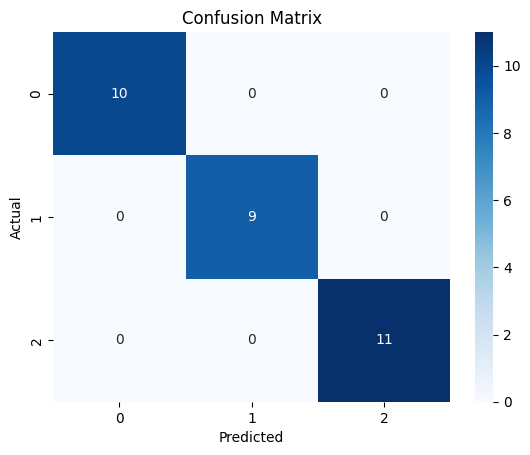

In [21]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (example dataset)
from sklearn.datasets import load_iris
data = load_iris()

# Create feature matrix (X) and target labels (y)
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()